# Support Vector Machines

## Init data

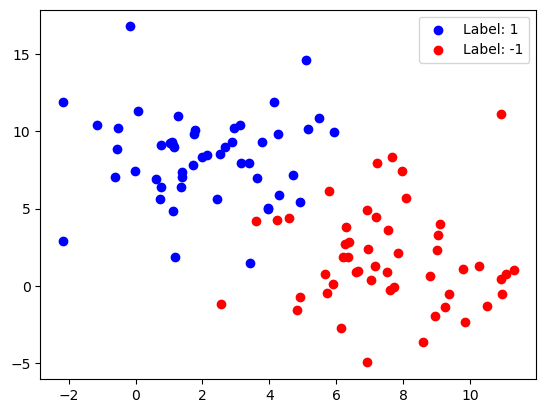

In [135]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
x1 = np.random.normal(loc=2, scale=2, size=N//2)
y1 = np.random.normal(loc=8, scale=3, size=N//2)
X1 = np.vstack([x1, y1])
Y1 = np.ones(N//2)

x2 = np.random.normal(loc=8, scale=2, size=N//2)
y2 = np.random.normal(loc=2, scale=3, size=N//2)
X2 = np.vstack([x2, y2])
Y2 = np.ones(N//2) * -1

X = np.hstack([X1, X2])
Y = np.hstack([Y1, Y2])

plt.scatter(x1, y1, color="blue", label="Label: 1")
plt.scatter(x2, y2, color="red", label="Label: -1")
plt.legend()
plt.show()


## Split data

In [136]:
indices = np.random.permutation(N)

X_shuffled = X[:, indices]
Y_shuffled = Y[indices]

frac_train = 0.8
train_size = int(N * frac_train)
val_size = N - train_size

X_train, Y_train = X_shuffled[:, :train_size], Y_shuffled[:train_size]
X_val, Y_val = X_shuffled[:, train_size:], Y_shuffled[train_size:]

## SVM

In [137]:
from numpy.linalg import norm

# Hinge loss
def hinge_loss(X, Y, w, b, C):
    t = Y * (w @ X + b)
    regularizer = 0.5 * norm(w)**2
    error = C * np.sum(np.maximum(0, 1 - t))

    loss = regularizer + error
    return loss

def compute_gradient(X, Y, w, b, C):

    t = Y * (w @ X + b)
    violations = t < 1
    dw = w + C * np.sum(np.where(violations, -Y * X, 0), axis=1)
    db = C * np.sum(np.where(violations, -Y, 0))

    return dw, db



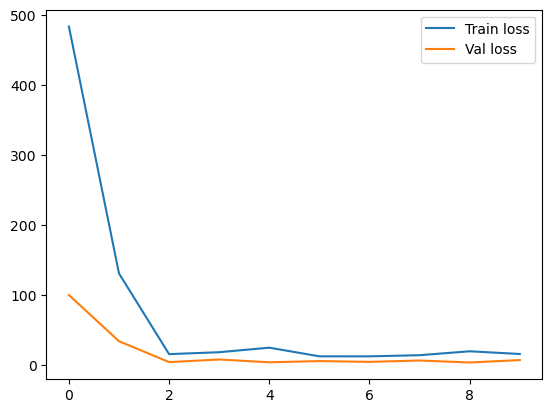

In [138]:
# We want to find a hyperplane f(x) = <w, x> + b that splits the data while maximizing the margin
# w is orthogonal to the hyperplane

w = np.random.normal(size=2)
b = np.random.normal()
C = 1 # Regularization parameter
eta = 0.01

train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):
    train_loss = hinge_loss(X_train, Y_train, w, b, C)
    train_losses.append(train_loss)

    val_loss = hinge_loss(X_val, Y_val, w, b, C)
    val_losses.append(val_loss)


    dw, db = compute_gradient(X_train, Y_train, w, b, C)

    w -= eta * dw
    b -= eta * db

plt.plot(range(epochs), train_losses, label="Train loss")
plt.plot(range(epochs), val_losses, label="Val loss")
plt.legend()
plt.show()

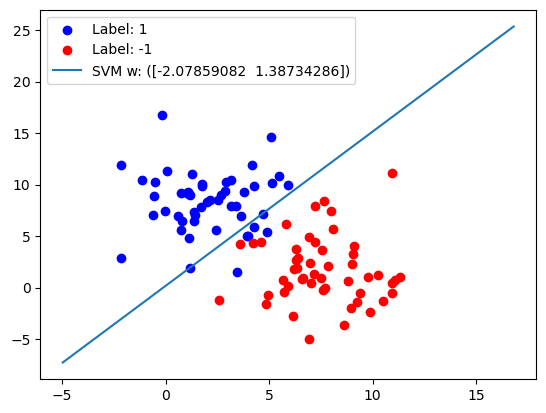

In [141]:
# w1 * x + w2 * y + b = 0 -> y = (-w1 * x - b) / w2

x = np.linspace(np.min(X), np.max(X))
y = (-w[0] * x - b) / w[1]

plt.scatter(x1, y1, color="blue", label="Label: 1")
plt.scatter(x2, y2, color="red", label="Label: -1")
plt.plot(x, y, label=f"SVM w: ({w})")
plt.legend()
plt.show()